# Part 3: Decision Trees

Decision trees are a popular machine learning algorithm used for both classification and regression tasks. They are easy to understand, visualize, and implement. They are also the base model used for more advanced algorithms like random forest and gradient boosting.

## What is a Decision Tree? (Self-Study)

A decision tree is a flowchart-like tree structure where an internal node represents a feature(or attribute), the branch represents a decision rule, and each leaf node represents the outcome. The topmost node in a tree is known as the root node.

![decision-tree](../assets/decision-tree.png)

### How Does a Decision Tree Work?

A decision tree splits the data into subsets based on the value of input features. This process is repeated recursively, resulting in a tree with decision nodes and leaf nodes.

**Decision Node**

A decision node has two or more branches, each representing values for the attribute tested.

**Leaf Node**

A leaf node represents a class label (in classification) or a continuous value (in regression).

### Building a Decision Tree

To build a decision tree, algorithms like ID3, C4.5, C5.0, and CART (Classification and Regression Trees) can be used. The most common algorithm used in `sklearn` is CART, which uses the **Gini impurity** or **entropy** as a criterion to create splits.

**Gini Impurity**

Gini impurity is a measure of how often a randomly chosen element from the set would be incorrectly labeled if it was randomly labeled according to the distribution of labels in the subset.

For a dataset with $ J $ classes, the Gini impurity of a node $ n $ is defined as:

$$ G(n) = 1 - \sum_{j=1}^{J} p_j^2 $$

where $ p_j $ is the fraction of items labeled with class $ j $ in the set.

- **Minimum (0)**: The Gini impurity is zero when all the samples in a node belong to a single class, indicating perfect purity.
- **Maximum ($1 - \frac{1}{J}$)**: The Gini impurity is maximized when the classes are evenly distributed across the node. For binary classification, this is when the classes are split 50/50 in a node, resulting in a Gini impurity of 0.5. For more classes, the maximum value decreases, reaching its theoretical maximum when each class has an equal probability.

![gini](../assets/gini.png)

**Entropy** 

Entropy is a measure of the randomness in the information being processed. The higher the entropy, the harder it is to draw any conclusions from that information. In the context of decision trees, it's used to quantify the impurity or disorder after a dataset is split on an attribute.

For a dataset with $ J $ classes, the entropy of a node $ n $ is defined as:

$$ H(n) = -\sum_{j=1}^{J} p_j \log_2(p_j) $$

where $ p_j $ is the proportion of the samples that belong to class $ j $.

- **Minimum (0)**: Entropy is zero when all samples at a node belong to the same class, which means there is no uncertainty or randomness.
- **Maximum ($ \log_2(J) $)**: Entropy is maximized when there is an equal number of samples from each class in the node, indicating the highest level of disorder or uncertainty. For binary classification, the maximum entropy is 1 (since $ \log_2(2) = 1 $). As the number of classes increases, the maximum possible entropy increases logarithmically.

### Information Gain

Information gain is based on the decrease in entropy after a dataset is split on an attribute. It is used to decide which attribute to split on at each step in building the tree.

For a dataset $ D $, split into subsets $ \{D_1, D_2, ..., D_k\} $ using feature $ A $, the information gain $ IG $ is defined as:

$$ IG(D, A) = H(D) - \sum_{i=1}^{k} \frac{|D_i|}{|D|} H(D_i) $$

| Symbol | Description |
|---|---|
|$ H(D) $ | entropy of the entire dataset |
|$ \|D_i\|/\|D\| $ | weight of the $ i $-th subset |
|$ H(D_i) $ | entropy of the $ i $-th subset |

### Advantages of Decision Trees

- Simple to understand and interpret.
- Requires little data preprocessing.
- Can handle both numerical and categorical data.

### Disadvantages of Decision Trees

- Prone to overfitting, especially with a lot of features.
- Can be unstable because small variations in the data might result in a completely different tree.

### Pruning a Decision Tree

Pruning is a technique used to reduce the size of decision trees by removing sections of the tree that provide little power in classifying instances. It reduces the complexity of the final classifier, hence reducing the risk of overfitting.

## Hands-On: Decision Tree Workflow
Let's apply the Decision Tree workflow on titanic dataset. We can skip the preprocessing and train-test split steps are they are identical.

In [1]:
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc

In [2]:
# Generate predictions on the test set and evaluate the model's performance
# using a confusion matrix, accuracy, precision, recall, and F1 score.

titanic = sns.load_dataset('titanic')
features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
target = 'survived'

X = titanic[features]
y = titanic[target]


# Preprocessing for numerical data
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Preprocessing for categorical data
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Bundle preprocessing for numerical and categorical data
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, ['age', 'sibsp', 'parch', 'fare']),
        ('cat', categorical_transformer, ['pclass', 'sex', 'embarked'])
    ])


In [3]:
model = DecisionTreeClassifier(criterion='gini', random_state=0)
param_grid = {
    'max_depth': [None, 2, 4, 6, 8, 10],
    'min_samples_split': [2, 4, 6, 8],
    'min_samples_leaf': [2, 4, 6, 8],
}

# Use f1 score as the metrics
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2, scoring='f1')

pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('grid_search', grid_search)
                          ])

In [4]:
# Split the data into training and testing sets. 
# Fit the full pipeline (preprocessing and model) on the training data.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
pipeline.fit(X_train, y_train)

Fitting 5 folds for each of 96 candidates, totalling 480 fits
[CV] END max_depth=None, min_samples_leaf=4, min_samples_split=2; total time=   0.1s[CV] END max_depth=None, min_samples_leaf=2, min_samples_split=2; total time=   0.1s[CV] END max_depth=None, min_samples_leaf=2, min_samples_split=4; total time=   0.1s[CV] END max_depth=None, min_samples_leaf=2, min_samples_split=6; total time=   0.1s[CV] END max_depth=None, min_samples_leaf=4, min_samples_split=2; total time=   0.1s



[CV] END max_depth=None, min_samples_leaf=2, min_samples_split=8; total time=   0.1s
[CV] END max_depth=None, min_samples_leaf=2, min_samples_split=2; total time=   0.1s

[CV] END max_depth=None, min_samples_leaf=2, min_samples_split=6; total time=   0.1s
[CV] END max_depth=None, min_samples_leaf=2, min_samples_split=4; total time=   0.1s[CV] END max_depth=None, min_samples_leaf=4, min_samples_split=2; total time=   0.1s

[CV] END max_depth=None, min_samples_leaf=2, min_samples_split=6; total time=   0.1s
[CV

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'sibsp', 'parch',
                                                   'fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['pclass', 'sex',
                                                   'embarked'])])),
                ('grid_search',
                 GridSearchCV(cv=5,
                              estimator=DecisionTreeClassifier(random_state=0),
                              n_jobs=-1,
                              param_grid={'max_depth': [None, 2, 4, 6, 8, 10],
                                          'min_samples_leaf': [2, 4, 6, 8],
                                          'min_samples_split': [2, 4, 6, 8]},
                              scoring='f1', verbose=2))])

f=6, min_samples_split=8; total time=   0.0s
[CV] END max_depth=10, min_samples_leaf=8, min_samples_split=2; total time=   0.0s
[CV] END max_depth=10, min_samples_leaf=6, min_samples_split=8; total time=   0.0s
[CV] END max_depth=10, min_samples_leaf=8, min_samples_split=2; total time=   0.0s
[CV] END max_depth=10, min_samples_leaf=8, min_samples_split=2; total time=   0.0s
[CV] END max_depth=10, min_samples_leaf=8, min_samples_split=2; total time=   0.0s
[CV] END max_depth=10, min_samples_leaf=8, min_samples_split=2; total time=   0.0s
[CV] END max_depth=10, min_samples_leaf=8, min_samples_split=4; total time=   0.0s
[CV] END max_depth=10, min_samples_leaf=8, min_samples_split=4; total time=   0.0s
[CV] END max_depth=10, min_samples_leaf=8, min_samples_split=4; total time=   0.0s
[CV] END max_depth=10, min_samples_leaf=8, min_samples_split=4; total time=   0.0s
[CV] END max_depth=10, min_samples_leaf=8, min_samples_split=4; total time=   0.0s
[CV] END max_depth=10, min_samples_leaf=8,

In [5]:
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Best Parameters: {best_params}")
print(f"Best Score: {best_score:.4f}")

Best Parameters: {'max_depth': 8, 'min_samples_leaf': 6, 'min_samples_split': 2}
Best Score: 0.7463


In [6]:
# Predict class labels for the test set and compute performance metrics (Accuracy, Precision, Recall, F1).
# Also compute ROC curve points and the Area Under the Curve (AUC) using predicted probabilities.

preds = pipeline.predict(X_test)

accuracy = accuracy_score(y_test, preds)
precision = precision_score(y_test, preds)
recall = recall_score(y_test, preds)
f1 = f1_score(y_test, preds)
fpr, tpr, thresholds = roc_curve(y_test, pipeline.predict_proba(X_test)[:,1])
roc_auc = auc(fpr, tpr)

In [7]:
print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')
print(f"AUC: {roc_auc:.2f}")

Accuracy: 0.83
Precision: 0.87
Recall: 0.67
F1 Score: 0.75
AUC: 0.89


## What `verbose` does in GridSearchCV

- `verbose=0` (default): silent, prints nothing while fitting
- `verbose=1`: prints one summary line, e.g. `Fitting 3 folds for each of 4 candidates, totalling 12 fits`, telling you the total number of fits upfront
- `verbose=2`: prints **one line per individual fit**, including the parameter combination and how long that fold took, e.g.:

[CV] END ...................max_depth=2, min_samples_split=2; total time=   0.0s

In the course notebooks, some grid searches run hundreds or thousands of fits (e.g. Random Forest: 5×5×4×4=400 combinations × cv=5 = 2000 fits). Using `verbose=2` lets you watch progress in real time and estimate how much longer it'll take, or tell whether it's stuck. Higher values (3, 4...) print even more internal detail. None of this affects the training result itself — it's purely for visibility into progress.

## Model Comparison — Titanic Survival Prediction

### Results (default threshold = 0.5)

| Model | Accuracy | Precision | Recall | F1 | AUC |
|---|---|---|---|---|---|
| Logistic Regression (default, C=1.0, L2) | 0.804 | 0.750 | 0.739 | 0.745 | 0.867 |
| ElasticNet (GridSearchCV, best: C=0.05, l1_ratio=0) | 0.793 | 0.750 | 0.696 | 0.722 | 0.871 |
| Decision Tree (GridSearchCV, best: max_depth=8, min_samples_leaf=6) | 0.832 | 0.868 | 0.667 | 0.754 | 0.886 |

### Key findings

**Default `LogisticRegression()` is not "unregularized."** It already applies L2 regularization at `C=1.0`. So the comparison with ElasticNet was never "regularized vs. not" — just two different regularization strengths.

**The ElasticNet's apparent underperformance is likely sampling noise, not a real effect.** On 5-fold CV within the training set, the selected `C=0.05` genuinely scored higher F1 (0.730) than the default `C=1.0` (0.715). But on the held-out test set, the ranking flipped (0.745 vs 0.722). Both gaps are similar in size — consistent with noise from a moderately small dataset (~712 train / ~179 test rows), not strong evidence that one model is truly better.

**Decision Tree favors Precision heavily over Recall at the default threshold.** Confusion matrix: TN=103, FP=7, FN=23, TP=46. It rarely mislabels a non-survivor as a survivor (FP=7 → high Precision), but misses a third of true survivors (FN=23 → low Recall) — an asymmetric error pattern, not a balanced one.

**AUC=0.886 (highest of the three) shows the tree is actually the strongest discriminator overall** — the low Recall is a threshold artifact, not a sign of a weaker model.

### Threshold sweep (Decision Tree)

| Threshold | Accuracy | Precision | Recall | F1 | AUC |
|---|---|---|---|---|---|
| 0.50 (default) | 0.821 | 0.825 | 0.681 | 0.746 | 0.886 |
| 0.40 | 0.827 (highest Accuracy) | 0.797 | 0.739 | 0.767 | 0.886 |
| 0.30 | 0.816 | 0.750 | 0.783 | 0.766 | 0.886 |
| 0.25 | 0.810 | 0.716 | 0.841 | 0.773 (highest F1) | 0.886 |
| 0.20 | 0.782 | 0.674 | 0.841 | 0.748 | 0.886 |

AUC stays exactly constant across all thresholds — it's computed by sweeping every threshold already, so it's threshold-independent by definition. Every other metric shifts, and each one peaks at a different threshold (Accuracy at 0.40, F1 at 0.25) — there is no single "best" threshold; it depends entirely on which metric matters most for the business goal.

### Takeaway

The 0.5 threshold used by `.predict()` is a hardcoded sklearn convention, not a value that's automatically optimal. Comparing models purely on default-threshold metrics — especially Recall or F1 — can understate a model's true quality if it has strong ranking ability (high AUC) but a conservative default decision boundary. Checking AUC and sweeping thresholds via `predict_proba()` gives a fuller picture than any single default-threshold snapshot.

```python
probs = pipeline.predict_proba(X_test)[:, 1]   
preds_custom = (probs >= 0.25).astype(int)     
```

## Hands-On: Visualizing the Decision Tree

Let's visualize the best decision tree model to better understand how it makes predictions.

In [9]:
from sklearn.tree import export_graphviz
import graphviz
import pandas as pd

In [10]:
# Extract the best decision tree model from the pipeline
best_tree = grid_search.best_estimator_

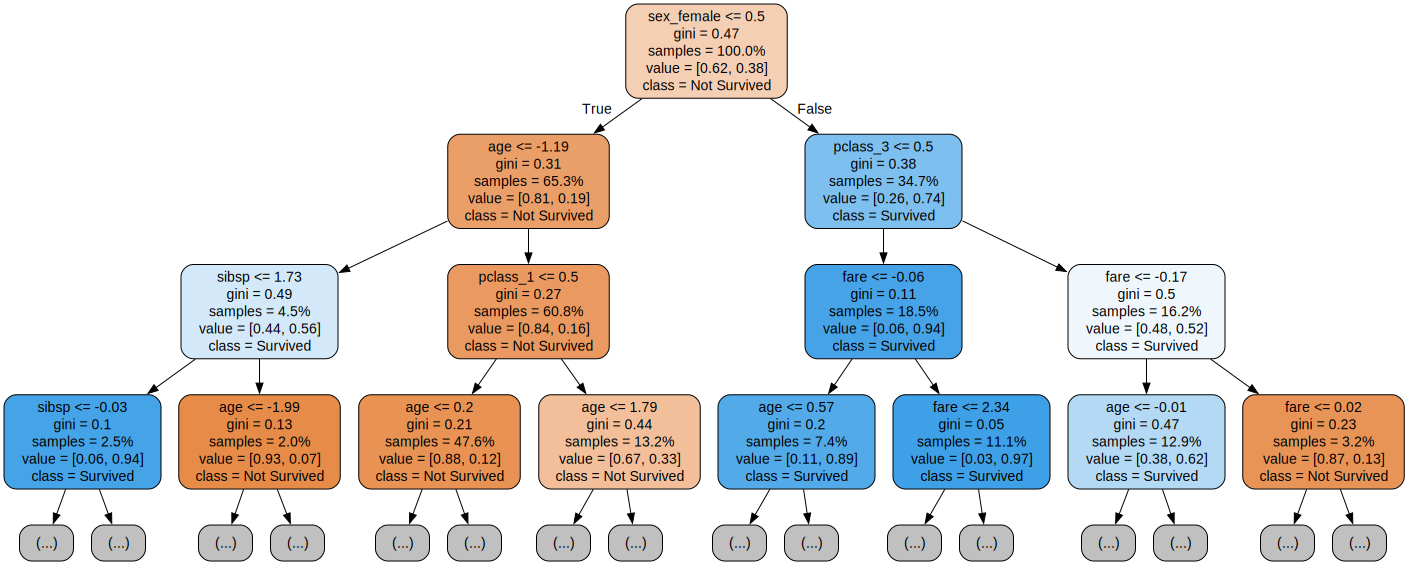

In [11]:
# Get feature names after preprocessing
# First, get the categorical feature names after one-hot encoding

cat_features = ['pclass', 'sex', 'embarked']
cat_transformer = preprocessor.named_transformers_['cat']
cat_encoder = cat_transformer.named_steps['onehot']
cat_feature_names = cat_encoder.get_feature_names_out(cat_features)

num_features = ['age', 'sibsp', 'parch', 'fare']

feature_names = list(num_features) + list(cat_feature_names)        # Combine feature names

dot_data = export_graphviz(
    best_tree,
    out_file=None,
    feature_names=feature_names,
    class_names=["Not Survived", "Survived"],
    filled=True,
    rounded=True,
    max_depth=3,  # Limit depth for better visualization
    proportion=True,
    precision=2
)

graph = graphviz.Source(dot_data, format="png")
graph